ASSIGNMENT 2 ( DATA INTEGRATION )

Caricamento datasets

In [227]:
import pandas as pd

# ======================
# 1. GO matrices (gene x go-term)
# ======================

bp = pd.read_csv("gene_go_matrix_propT_rel-is_a-part_of_ont-BP.csv", index_col=0)
cc = pd.read_csv("gene_go_matrix_propT_rel-is_a-part_of_ont-CC.csv", index_col=0)
mf = pd.read_csv("gene_go_matrix_propT_rel-is_a-part_of_ont-MF.csv", index_col=0)

# ======================
# 2. HPO matrix (gene x hpo-term)
# ======================
hpo = pd.read_csv("gene_hpo_matrix_binary_withAncestors_namespace_Phenotypic abnormality.csv",
                  index_col=0)

# ======================
# 3. GO term depth tables
# ======================
depth_bp = pd.read_csv("goterm_depth_propT_rel-is_a-part_of_ont-BP.csv")
depth_cc = pd.read_csv("goterm_depth_propT_rel-is_a-part_of_ont-CC.csv")
depth_mf = pd.read_csv("goterm_depth_propT_rel-is_a-part_of_ont-MF.csv")

# ======================
# Quick check
# ======================
bp.shape, cc.shape, mf.shape, hpo.shape


((5183, 9873), (5183, 1478), (5183, 3258), (5183, 10185))

Visualizzzione distribuzione profondità

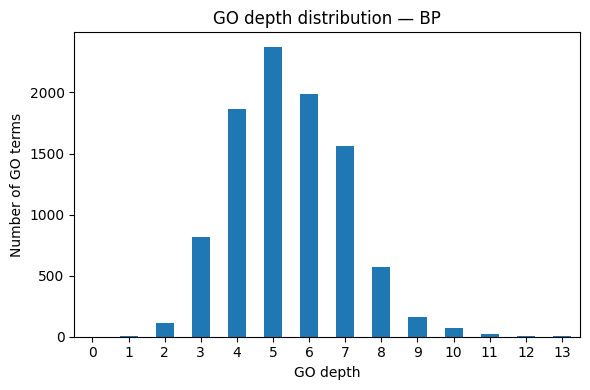

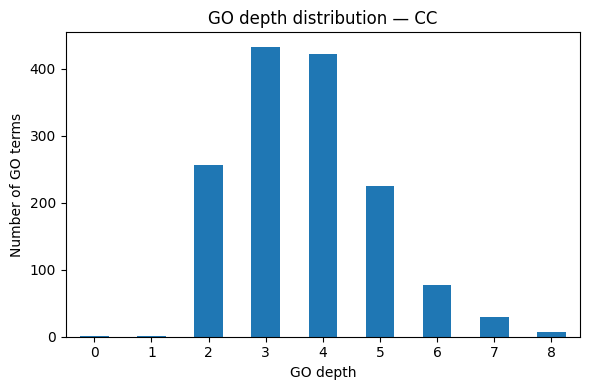

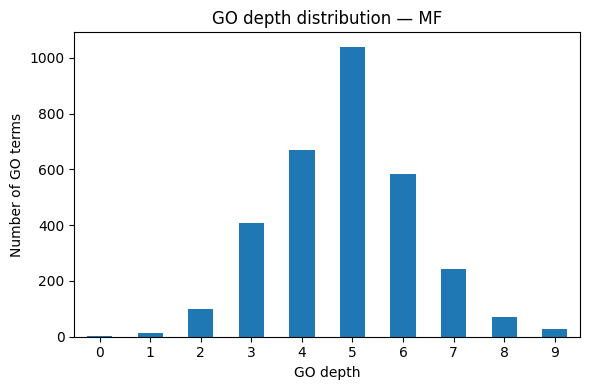

In [228]:
import matplotlib.pyplot as plt

# Extract depths as Series (already consistent with your code)
depth_bp_series = depth_bp.iloc[0, 2:].astype(int)
depth_cc_series = depth_cc.iloc[0, 2:].astype(int)
depth_mf_series = depth_mf.iloc[0, 2:].astype(int)


def plot_depth_distribution(depth_series, title):
    depth_counts = depth_series.value_counts().sort_index()

    plt.figure(figsize=(6,4))
    depth_counts.plot(kind="bar")
    plt.xlabel("GO depth")
    plt.ylabel("Number of GO terms")
    plt.title(title)
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()
    #print(depth_counts)  # this also shows the numbers in the console

# BP
plot_depth_distribution(depth_bp_series, "GO depth distribution — BP")

# CC
plot_depth_distribution(depth_cc_series, "GO depth distribution — CC")

# MF
plot_depth_distribution(depth_mf_series, "GO depth distribution — MF")


Filtraggio dei GO terms con profondità : 3

In [229]:
import pandas as pd

# ======================
# STEP 1 — Choose the depth threshold
# ======================
DEPTH_THRESHOLD = 3   # you can increase to 4 if you want only very specific terms
#DEPTH_THRESHOLDS = 4

# ======================
# STEP 2 — Select GO terms with sufficient depth
# ======================

# The depth dataframes have GO terms as column headers (from index 2 onwards)
# and their depths in the first row (index 0) from index 2 onwards.
# We need to extract this information into a Series for easier filtering.

# For depth_bp:
depth_bp_series = depth_bp.iloc[0, 2:].astype(int)  # Convert depths to int
valid_bp_terms = depth_bp_series[depth_bp_series >= DEPTH_THRESHOLD].index.tolist()

# For depth_cc:
depth_cc_series = depth_cc.iloc[0, 2:].astype(int)  # Convert depths to int
valid_cc_terms = depth_cc_series[depth_cc_series >= DEPTH_THRESHOLD].index.tolist()

# For depth_mf:
depth_mf_series = depth_mf.iloc[0, 2:].astype(int)  # Convert depths to int
valid_mf_terms = depth_mf_series[depth_mf_series >= DEPTH_THRESHOLD].index.tolist()


# ======================
# STEP 3 — Filter GO matrices on valid columns
# ======================

bp_filtered = bp.loc[:, bp.columns.isin(valid_bp_terms)]
cc_filtered = cc.loc[:, cc.columns.isin(valid_cc_terms)]
mf_filtered = mf.loc[:, mf.columns.isin(valid_mf_terms)]


# ======================
# STEP 4 — Remove any fully empty columns
# ======================

bp_filtered = bp_filtered.loc[:, bp_filtered.sum(axis=0) > 0]
cc_filtered = cc_filtered.loc[:, cc_filtered.sum(axis=0) > 0]
mf_filtered = mf_filtered.loc[:, mf_filtered.sum(axis=0) > 0]


# ======================
# STEP 5 — Verification output
# ======================

print("Filtering completed:\n")
print(f"BP: {bp.shape[1]} → {bp_filtered.shape[1]} GO terms retained")
print(f"CC: {cc.shape[1]} → {cc_filtered.shape[1]} GO terms retained")
print(f"MF: {mf.shape[1]} → {mf_filtered.shape[1]} GO terms retained")


Filtering completed:

BP: 9873 → 9439 GO terms retained
CC: 1478 → 1193 GO terms retained
MF: 3258 → 3042 GO terms retained


DATA INTEGRATION CON MOFA

import mofapy

In [ ]:
pip install  mofax


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.0 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 128 kB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 2.4 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 3.5 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 53 kB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 113 kB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 3.2 MB/s eta 0:00:01
You should consider upgrading via the 

preparazione dati per mofa

In [230]:
import numpy as np

# Intersection of genes present in all matrices
common_genes = (
    set(bp_filtered.index)
    & set(cc_filtered.index)
    & set(mf_filtered.index)
    & set(hpo.index)
)

common_genes = sorted(common_genes)

print(f"Genes shared across all views: {len(common_genes)}")

# Subselect and reorder matrices
bp_mofa  = bp_filtered.loc[common_genes]
cc_mofa  = cc_filtered.loc[common_genes]
mf_mofa  = mf_filtered.loc[common_genes]
hpo_mofa = hpo.loc[common_genes]


Genes shared across all views: 5183


Impostazione MOFA

In [231]:
from mofapy2.run.entry_point import entry_point
import pandas as pd

# ============================
# 1. View, sample, and feature names
# ============================

view_names = ["BP", "CC", "MF", "HPO"]
groups_names = ["genes"]   # we only have a single group
sample_names = bp_mofa.index.tolist()  # same for all views

features_names = [
    bp_mofa.columns.tolist(),
    cc_mofa.columns.tolist(),
    mf_mofa.columns.tolist(),
    hpo_mofa.columns.tolist()
]

# ============================
# 2. Construct the "data" list
#    structure: data[view][group] = matrix (samples x features)
# ============================

data = [
    [bp_mofa.values],   # BP view, group "genes"
    [cc_mofa.values],   # CC view
    [mf_mofa.values],   # MF view
    [hpo_mofa.values]   # HPO view
]

likelihoods = ["bernoulli", "bernoulli", "bernoulli", "bernoulli"]

# ============================
# 3. Initialize entry_point and set data
# ============================

ent = entry_point()

# (optional) general data options
ent.set_data_options(
    scale_views = False,
    scale_groups = False
)

# Key step: use set_data_matrix
ent.set_data_matrix(
    data = data,
    likelihoods = likelihoods,
    views_names = view_names,
    groups_names = groups_names,
    samples_names = [sample_names],   # list per group
    features_names = features_names   # list per view
)



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Successfully loaded view='BP' group='genes' with N=5183 samples and D=9439 features...
Successfully loaded view='CC' group='genes' with N=5183 samples and D=1193 features...
Successfully loaded view='MF' group='genes' with N=5183 samples and D=3042 features...
Successfully loaded view='HPO' group='genes' with N=5183 samples and D=10185 features...




Impostazione modello e training

In [233]:
# ============================
# MODEL OPTIONS
# ============================

# All views are binary → bernoulli
likelihoods = ["bernoulli"] * len(view_names)

ent.set_model_options(
    factors = 15,          # you can increase to 15 if you want more factors
    #likelihoods = likelihoods
)

# ============================
# TRAIN OPTIONS
# ============================

ent.set_train_options(
    iter = 500,            # if it converges well you can increase it
    convergence_mode = "fast",
    verbose = False,
    seed = 42              # for reproducibility
)

# ============================
# BUILD + RUN
# ============================

ent.build()
ent.run()


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (BP): bernoulli
- View 1 (CC): bernoulli
- View 2 (MF): bernoulli
- View 3 (HPO): bernoulli




######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -258454611.48 

Iteration 1: time=15.37, ELBO=-133646524.67, deltaELBO=124808086.816 (48.29013733%), Factors=15
Iteration 2: time=14.17, ELBO=-85545127.53, deltaELBO=48101397.142 (18.61115840%), Factors=15
Iteration 3: time=14.66, ELBO=-85432746.38, deltaELBO=112381.142 (0.04348196%), Factors=15
Iteration 4: time=14.38, ELBO=-85414599.98, deltaELBO=18146.408 (0.00702112%), Factors=15
Iteration 5: time=14.58, ELBO=-85401001.37, deltaELBO=13598.609 (0.00526151%), Factors=15
Iteration 6: time=14.44, ELBO=-853

Normalizzazione dei fattori

recupero modello e Z_df

In [234]:
model = ent.model
# 1) Retrieve the factor matrix (samples × factors)
Z = model.nodes["Z"].getExpectation()   # shape: n_samples x n_factors

# 2) Build factor names
n_factors = Z.shape[1]
factor_names = [f"Factor_{i+1}" for i in range(n_factors)]

# 3) sample_names is the list of genes you used when calling set_data_matrix
Z_df = pd.DataFrame(Z, index=sample_names, columns=factor_names)

Z_df.head()


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15
10,-1.528164,-0.219360,-0.484415,-0.629754,-0.789675,-0.245350,-0.070914,0.438244,-0.136542,-0.441986,0.265167,0.258670,-0.582551,0.165055,-0.226908
16,1.797280,1.568492,1.285880,2.524589,0.016328,0.287927,0.019602,0.115844,-0.513638,0.519985,-4.455684,0.119780,1.431877,-0.106695,-0.662328
18,-0.093573,0.643556,-0.519884,1.134285,0.142406,-0.591759,-0.086393,0.265990,-0.361446,-0.384800,0.111004,0.329112,-0.195219,-0.160302,-0.669971
19,-0.630183,0.260709,1.130637,0.406203,0.954438,0.043279,-0.103697,1.167427,-0.030682,1.093844,0.274660,0.913916,0.775418,1.342394,-0.320074
20,-0.224720,0.489900,-0.718707,0.549555,0.655517,-0.209147,-0.110507,0.681516,-0.426076,-0.520482,-0.189728,0.387645,0.509050,0.479071,-0.013067


In [236]:
Z_df.shape


(5183, 15)

In [237]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# Z_scaled = scaler.fit_transform(Z_df.values)  # same shape as Z_df but scaled

# print(Z_scaled)

# =============================
# 2) Create the scaled version of the factor matrix
# =============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# This returns a NumPy array with standardized values
Z_scaled = scaler.fit_transform(Z_df.values)

# Convert back to a DataFrame (tabular form)
Z_scaled_df = pd.DataFrame(
    Z_scaled,
    index=Z_df.index,      # same gene names
    columns=Z_df.columns   # same factor names
)

# Show preview
Z_scaled_df.head()


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15
10,-1.167742,-0.195179,-0.500654,-0.654570,-0.812740,-0.237030,-0.065600,0.425406,-0.125581,-0.486207,0.258761,0.251934,-0.618392,0.163288,-0.225033
16,1.349100,1.292994,1.302222,2.591386,0.024552,0.299685,0.021864,0.096268,-0.500984,0.518629,-4.650380,0.110923,1.470237,-0.120048,-0.660778
18,-0.081980,0.523096,-0.536776,1.160703,0.155524,-0.585673,-0.080557,0.249551,-0.349475,-0.426473,0.098449,0.323453,-0.216793,-0.175941,-0.668426
19,-0.488111,0.204421,1.144122,0.411474,0.999080,0.053459,-0.097278,1.169830,-0.020196,1.118058,0.268633,0.917193,0.789597,1.390823,-0.318268
20,-0.181238,0.395195,-0.739258,0.558990,0.688555,-0.200594,-0.103859,0.673763,-0.413814,-0.568202,-0.214278,0.382881,0.513418,0.490693,-0.011033


matrice di similarità integrata


In [238]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Use Z_scaled if you applied scaling, otherwise Z_df.values
similarity_matrix = cosine_similarity(Z_scaled)

# Convert to DataFrame with rows/columns = genes
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=Z_df.index,
    columns=Z_df.index
)

similarity_df.iloc[:5, :5]


,10,16,18,19,20
10,1.000000,-0.537270,0.067727,-0.181525,0.015518
16,-0.537270,1.000000,0.218143,0.163049,0.223054
18,0.067727,0.218143,1.000000,0.015544,0.604291
19,-0.181525,0.163049,0.015544,1.000000,0.332780
20,0.015518,0.223054,0.604291,0.332780,1.000000


Visualizzazione similarità

<Axes: >

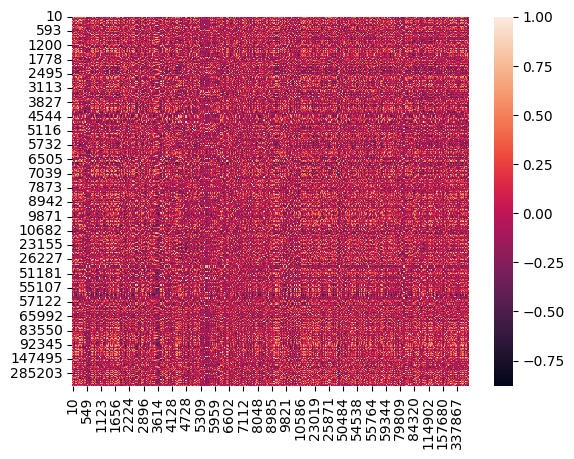

In [241]:
import seaborn as sns
sns.heatmap(similarity_df)


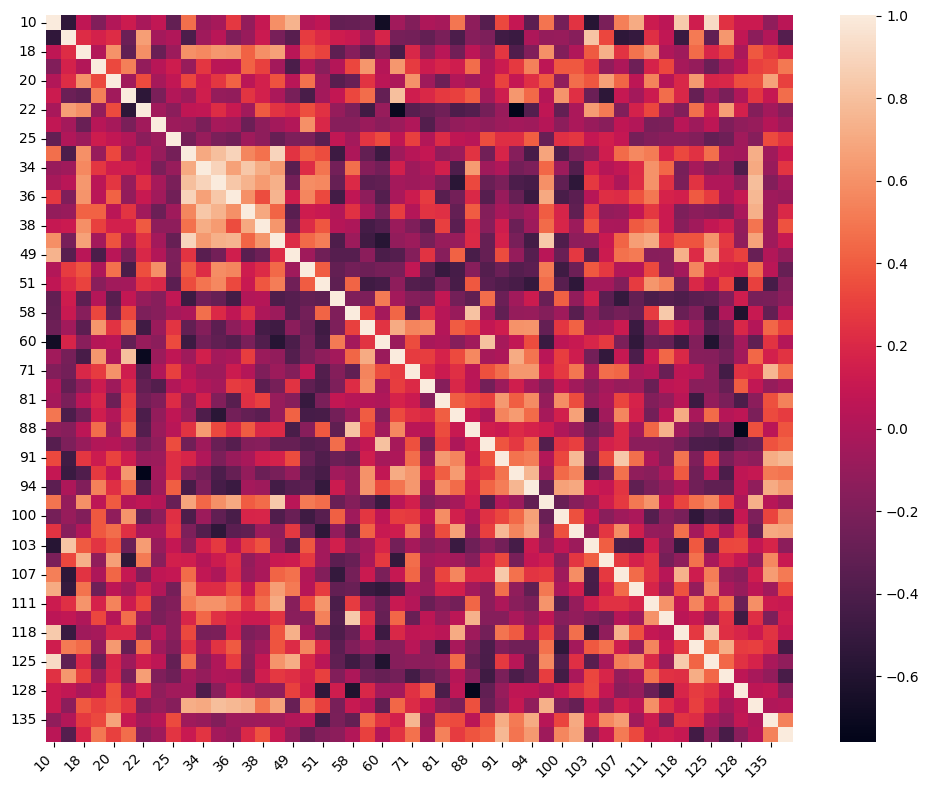

In [245]:
#sns.heatmap(similarity_df.iloc[:50, :50])
plt.figure(figsize=(10, 8))
ax = sns.heatmap(similarity_df.iloc[:50, :50])

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Optional: rotate y-axis labels too
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()



CLUSTERING

In [246]:
from sklearn.cluster import SpectralClustering

# Z_scaled: matrix (n_genes × n_factors) you used for the cosine similarity
sc = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)

labels = sc.fit_predict(Z_scaled)
Z_df["cluster"] = labels
Z_df

#np.unique(labels, return_counts=True)


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,cluster
10,-1.528164,-0.219360,-0.484415,-0.629754,-0.789675,-0.245350,-0.070914,0.438244,-0.136542,-0.441986,0.265167,0.258670,-0.582551,0.165055,-0.226908,0
16,1.797280,1.568492,1.285880,2.524589,0.016328,0.287927,0.019602,0.115844,-0.513638,0.519985,-4.455684,0.119780,1.431877,-0.106695,-0.662328,0
18,-0.093573,0.643556,-0.519884,1.134285,0.142406,-0.591759,-0.086393,0.265990,-0.361446,-0.384800,0.111004,0.329112,-0.195219,-0.160302,-0.669971,0
19,-0.630183,0.260709,1.130637,0.406203,0.954438,0.043279,-0.103697,1.167427,-0.030682,1.093844,0.274660,0.913916,0.775418,1.342394,-0.320074,0
20,-0.224720,0.489900,-0.718707,0.549555,0.655517,-0.209147,-0.110507,0.681516,-0.426076,-0.520482,-0.189728,0.387645,0.509050,0.479071,-0.013067,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105371045,-0.445358,0.399338,0.865613,-0.411385,-0.476186,0.217040,-0.097974,0.366010,-0.317372,-0.177008,0.394441,0.182332,-0.613813,-0.144486,-0.292844,0
105804841,-0.711215,0.059987,-0.921559,-1.503491,-0.796506,-0.393623,-0.135441,0.512142,-0.178670,-0.152628,0.164787,0.017818,0.155049,0.295285,1.073992,0
109580095,-1.580596,-0.339899,-0.120653,-0.623555,-0.797629,-0.249815,-0.067868,0.481016,-0.205920,-0.647687,0.108054,0.404596,-0.023097,0.273855,-0.297040,0
111365204,-1.276651,-0.061197,-0.580252,-0.823566,-0.835968,0.828288,-0.072778,0.435680,-0.275706,-0.427081,-0.076217,0.236644,-0.549633,0.064159,-0.225338,0


Numero di cluster ottimale

In [247]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

Ks = range(2, 11)   # try k from 2 to 10
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(Z_scaled)
    score = silhouette_score(Z_scaled, labels_k)
    sil_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

best_k = Ks[int(np.argmax(sil_scores))]
print("Chosen k (highest silhouette):", best_k)


k=2, silhouette=0.3331
k=3, silhouette=0.3357
k=4, silhouette=0.1388
k=5, silhouette=0.1357
k=6, silhouette=0.1400
k=7, silhouette=0.1653
k=8, silhouette=0.1792
k=9, silhouette=0.1695
k=10, silhouette=0.1903
Chosen k (highest silhouette): 3


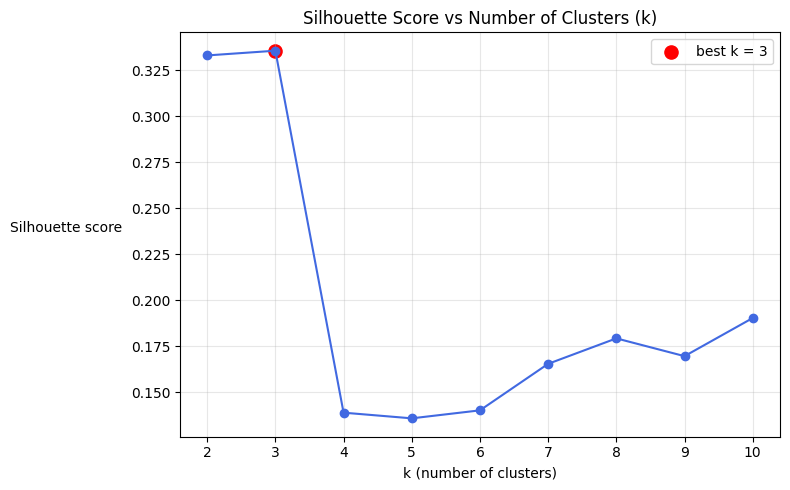

In [282]:
# -----------------------------------------
# Plot silhouette vs K
# -----------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(Ks, sil_scores, marker='o', linestyle='-', color='royalblue')
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score                           ", rotation=0)

# Highlight the best k
plt.scatter(best_k, max(sil_scores), color='red', s=90, label=f"best k = {best_k}")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Spectral with optimal k

Pulisco la Z_df

In [249]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# 1) Start from the original Z_df (without the cluster column inside)
Z_clean = Z_df.copy()

# If you already added the 'cluster' column, remove it for safety:
if "cluster" in Z_clean.columns:
    Z_clean = Z_clean.drop(columns=["cluster"])

# 2) Remove factors with zero variance (constant columns)
var_factors = Z_clean.var()
Z_clean = Z_clean.loc[:, var_factors > 0]

print("Factors used:", Z_clean.shape[1])

# 3) Remove any genes (rows) with NaN in their factors
Z_clean = Z_clean.dropna(axis=0)
print("Genes remaining after dropna:", Z_clean.shape[0])

# 4) Standardization
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z_clean.values)

# 5) Recompute similarity (cosine)
similarity_matrix = cosine_similarity(Z_scaled)

sim = pd.DataFrame(
    similarity_matrix,
    index=Z_clean.index,
    columns=Z_clean.index
)

# 6) Final check for NaN
print("NaN in similarity:", sim.isna().sum().sum())


Factors used: 15
Genes remaining after dropna: 5183
NaN in similarity: 0


In [250]:
import numpy as np

print("Total NaNs in sim:", sim.isna().sum().sum())

# See which genes have at least one NaN in their row/column
mask_nan_rows = sim.isna().any(axis=1)   # True = row with at least one NaN
genes_with_nan = sim.index[mask_nan_rows]

print("Number of genes with at least one NaN:", mask_nan_rows.sum())
print("First genes with NaN:", genes_with_nan[:10].tolist())


Total NaNs in sim: 0
Number of genes with at least one NaN: 0
First genes with NaN: []


In [251]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(
    n_clusters=best_k,
    affinity='nearest_neighbors',  # it builds the affinity matrix internally
    n_neighbors=10,                # you can vary this (5–20)
    random_state=42
)

labels = sc.fit_predict(Z_scaled)

Z_clean["cluster"] = labels

# Distribution of genes per cluster
unique, counts = np.unique(labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n} genes")


Cluster 0: 5136 genes
Cluster 1: 29 genes
Cluster 2: 18 genes


In [252]:
# Restrict to genes used in Z_clean
sim_for_plot = sim.loc[Z_clean.index, Z_clean.index]

# Order according to clusters
order = np.argsort(Z_clean["cluster"].values)
genes_ordered = sim_for_plot.index[order]

sim_ordered = sim_for_plot.loc[genes_ordered, genes_ordered]


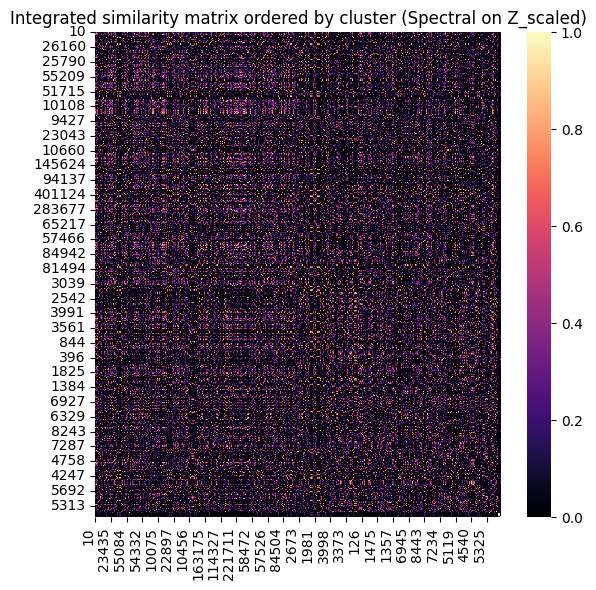

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
ax = sns.heatmap(sim_ordered, cmap="magma", vmin=0, vmax=1)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

# Optional: rotate y-axis labels too (if needed)
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Integrated similarity matrix ordered by cluster (Spectral on Z_scaled)")
plt.tight_layout()
plt.show()


In [187]:
pip install umap-learn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


UMAP

In [269]:
import umap
import numpy as np
import pandas as pd

# UMAP with standard parameters for continuous data
reducer = umap.UMAP(
    n_neighbors=15,         # how much you look "locally"
    min_dist=0.1,           # how compact the clusters should be
    metric='euclidean',
    random_state=42
)

umap_coords = reducer.fit_transform(Z_scaled)

# Build a DataFrame for convenience
UMAP_df = pd.DataFrame({
    "UMAP1": umap_coords[:,0],
    "UMAP2": umap_coords[:,1],
    "cluster": Z_clean["cluster"].values
}, index=Z_clean.index)

UMAP_df


,UMAP1,UMAP2,cluster
10,5.373604,6.273725,0
16,10.070495,-0.342112,0
18,7.729909,1.876693,0
19,4.529934,3.095731,0
20,7.971571,2.241178,0
...,...,...,...
105371045,4.036974,3.645935,0
105804841,6.118507,4.489820,0
109580095,5.333728,6.122866,0
111365204,5.708459,7.392431,0


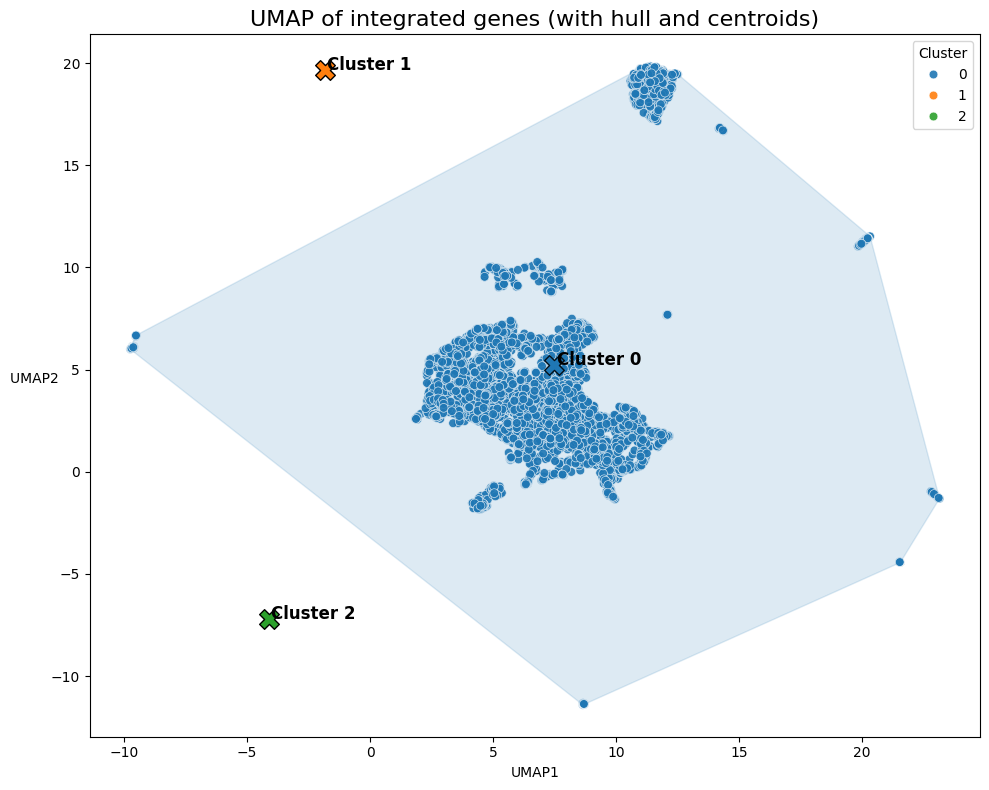

In [283]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

plt.figure(figsize=(10, 8))

# cluster palette
palette = sns.color_palette("tab10", len(UMAP_df["cluster"].unique()))

# scatter plot of points
sns.scatterplot(
    data=UMAP_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette=palette,
    s=40,
    alpha=0.9
)

# Convex hull + centroids
for c in UMAP_df["cluster"].unique():
    subset = UMAP_df[UMAP_df["cluster"] == c][["UMAP1", "UMAP2"]].values
    
    # compute centroid
    centroid = subset.mean(axis=0)
    
    # draw centroid
    plt.scatter(centroid[0], centroid[1], marker="X", s=200, c=[palette[c]], edgecolor="black")
    plt.text(centroid[0]+0.1, centroid[1], f"Cluster {c}", fontsize=12, weight="bold")
    
    # Convex hull (only if > 3 points)
    if subset.shape[0] > 3:
        hull = ConvexHull(subset)
        hull_points = subset[hull.vertices]
        plt.fill(
            hull_points[:,0],
            hull_points[:,1],
            alpha=0.15,
            color=palette[c]
        )

plt.title("UMAP of integrated genes (with hull and centroids)", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2     ", rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


Interpretazione dei cluster (GO & HPO enrichment)

estrazione geni per clusters

In [271]:
clusters = {}
for c in sorted(Z_clean["cluster"].unique()):
    clusters[c] = Z_clean.index[Z_clean["cluster"] == c].tolist()

clusters


{np.int32(0): [10,
  16,
  18,
  19,
  20,
  21,
  22,
  24,
  31,
  34,
  35,
  36,
  37,
  38,
  39,
  49,
  50,
  51,
  54,
  58,
  59,
  60,
  70,
  71,
  72,
  81,
  87,
  88,
  90,
  91,
  93,
  94,
  95,
  100,
  102,
  103,
  104,
  107,
  109,
  111,
  112,
  118,
  120,
  125,
  126,
  128,
  132,
  135,
  150,
  151,
  153,
  155,
  158,
  162,
  164,
  174,
  175,
  176,
  178,
  181,
  182,
  183,
  185,
  189,
  190,
  191,
  196,
  197,
  203,
  204,
  207,
  208,
  210,
  212,
  213,
  215,
  217,
  220,
  224,
  226,
  229,
  238,
  240,
  241,
  242,
  249,
  257,
  258,
  265,
  267,
  268,
  269,
  270,
  271,
  272,
  274,
  275,
  283,
  284,
  285,
  286,
  287,
  288,
  291,
  308,
  311,
  318,
  324,
  326,
  330,
  331,
  335,
  336,
  338,
  344,
  345,
  348,
  351,
  353,
  355,
  356,
  359,
  361,
  362,
  367,
  368,
  372,
  375,
  383,
  387,
  396,
  399,
  401,
  402,
  403,
  407,
  410,
  411,
  412,
  415,
  421,
  427,
  429,
  435,
  439,
  440

Funzione che calcola i GO/HPO caratteristici

In [273]:
def cluster_enrichment(binary_matrix, gene_list, top_k=10):
    """
    binary_matrix: DataFrame (genes × GOterms)
    gene_list: list of genes in the cluster
    """
    # subset cluster
    sub = binary_matrix.loc[gene_list]
    
    # frequency inside the cluster
    freq_cluster = sub.mean(axis=0)
    
    # total frequency
    freq_total = binary_matrix.mean(axis=0)
    
    # enrichment ratio
    enrichment = (freq_cluster + 1e-6) / (freq_total + 1e-6)
    
    # assemble into a dataframe
    df = pd.DataFrame({
        "freq_cluster": freq_cluster,
        "freq_total": freq_total,
        "enrichment": enrichment
    })
    
    return df.sort_values("enrichment", ascending=False).head(top_k)


Calcolo dei GO terms caratteristici per ogni cluster

In [274]:
# Biological Process (BP)
for c in clusters:
    print(f"\n=== Cluster {c} — BP ===")
    print(cluster_enrichment(bp_filtered, clusters[c], top_k=10))


# Cellular Component (CC)
for c in clusters:
    print(f"\n=== Cluster {c} — CC ===")
    print(cluster_enrichment(cc_filtered, clusters[c], top_k=10))


# Molecular Function (MF)
for c in clusters:
    print(f"\n=== Cluster {c} — MF ===")
    print(cluster_enrichment(mf_filtered, clusters[c], top_k=10))



=== Cluster 0 — BP ===
            freq_cluster  freq_total  enrichment
GO.0006629      0.088785    0.087980    1.009151
GO.0030001      0.060358    0.059811    1.009151
GO.0050801      0.051986    0.051515    1.009151
GO.0055080      0.050623    0.050164    1.009151
GO.0006954      0.044782    0.044376    1.009151
GO.0006873      0.042835    0.042446    1.009151
GO.0008610      0.042640    0.042254    1.009151
GO.0030003      0.041667    0.041289    1.009151
GO.0032787      0.040888    0.040517    1.009151
GO.0044782      0.039914    0.039552    1.009151

=== Cluster 1 — BP ===
            freq_cluster  freq_total  enrichment
GO.0042704      0.068966    0.000386  178.264756
GO.1902729      0.034483    0.000193  177.807743
GO.1905006      0.034483    0.000193  177.807743
GO.1905223      0.034483    0.000193  177.807743
GO.0002651      0.034483    0.000193  177.807743
GO.1905317      0.034483    0.000193  177.807743
GO.0035906      0.034483    0.000193  177.807743
GO.0021647      0.034

Costruiamo il grafo dei geni

In [66]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.6 MB 4.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [275]:
import networkx as nx
import numpy as np

# 1) Use only the genes for which we have the cluster assignment
genes = Z_clean.index
sim_sub = sim.loc[genes, genes]

# 2) Similarity threshold to create edges
THRESHOLD = 0.8  # you can try 0.6, 0.8, etc.

G = nx.Graph()

# Add nodes with 'cluster' attribute
for gene in genes:
    G.add_node(gene, cluster=int(Z_clean.loc[gene, "cluster"]))

# Add edges for similarity >= threshold
for i, g1 in enumerate(genes):
    for j in range(i+1, len(genes)):
        g2 = genes[j]
        w = sim_sub.loc[g1, g2]
        if w >= THRESHOLD:
            G.add_edge(g1, g2, weight=float(w))

print("Nodes in graph:", G.number_of_nodes())
print("Edges in graph (sim >= threshold):", G.number_of_edges())


Nodes in graph: 5183
Edges in graph (sim >= threshold): 124078


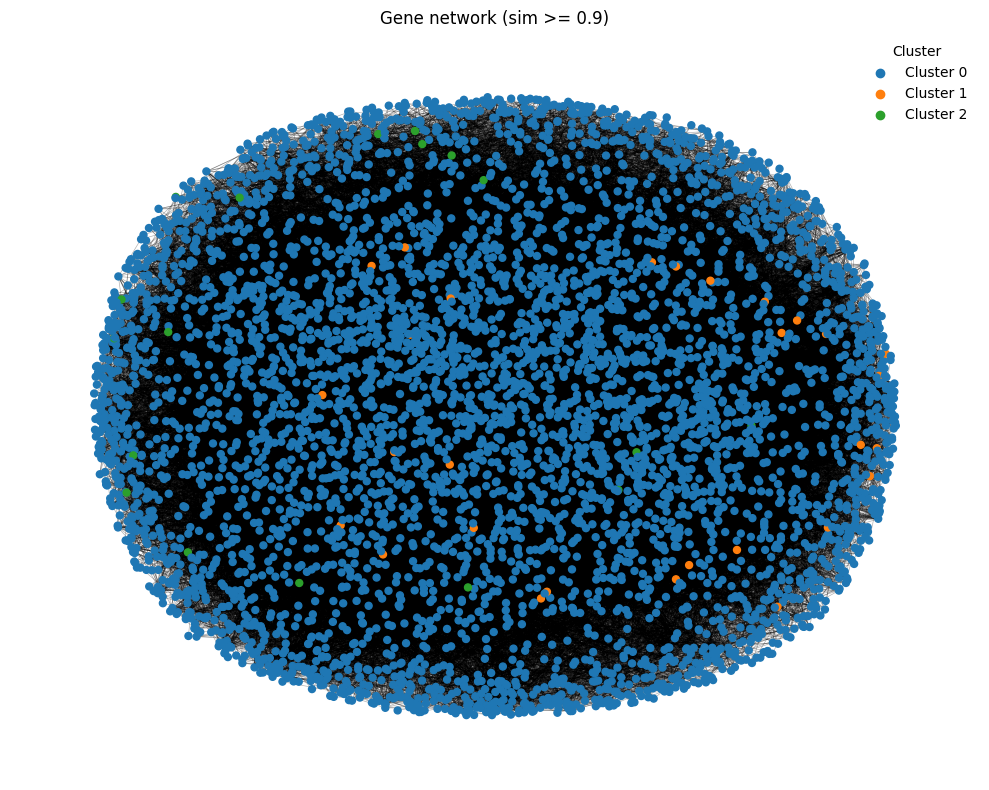

In [337]:
import matplotlib.pyplot as plt

# Layout (may be slow if there are many nodes)
pos = nx.spring_layout(G, seed=42, k=0.5)  # k controls distance between nodes

# Build a color list for each node based on cluster
clusters = nx.get_node_attributes(G, "cluster")
unique_clusters = sorted(set(clusters.values()))

# simple palette
cluster_palette = {
    "0": "#1f77b4",  # blue
    "1": "#ff7f0e",  # orange
    "2": "#2ca02c"   # green
}

#colors_map = plt.cm.get_cmap("tab10", len(unique_clusters))
node_colors = [cluster_palette[str(clusters[node])] for node in G.nodes()]

plt.figure(figsize=(10, 8))

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3,
    width=0.5
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=25
)

# (Optional) omit gene labels, otherwise it's unreadable

# Legend for clusters (manually created)
for c in unique_clusters:
    plt.scatter([], [], color=cluster_palette[str(c)], label=f"Cluster {c}")
plt.legend(scatterpoints=1, frameon=False, title="Cluster")

plt.title(f"Gene network (sim >= {THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()


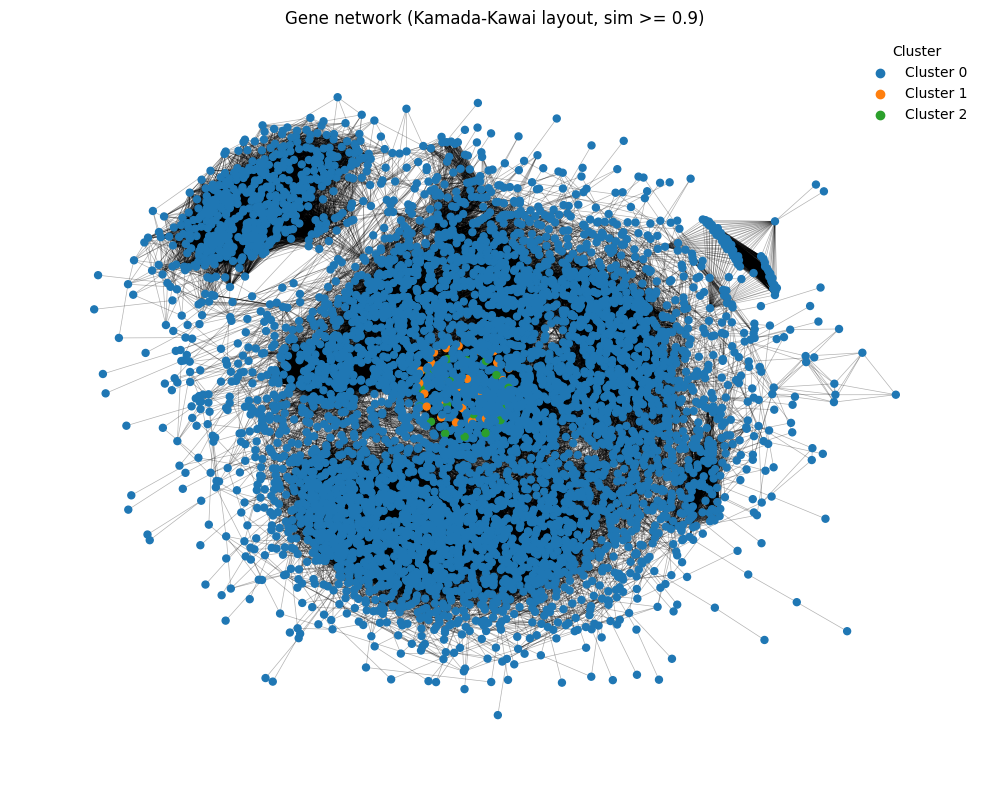

In [338]:
import matplotlib.pyplot as plt

# Kamada-Kawai layout (more tidy, more uniform edge lengths)
pos = nx.kamada_kawai_layout(G)

# Build colors for clusters
clusters = nx.get_node_attributes(G, "cluster")
unique_clusters = sorted(set(clusters.values()))

# Same palette as before
cluster_palette = {
    "0": "#1f77b4",  # blue
    "1": "#ff7f0e",  # orange
    "2": "#2ca02c"   # green
}

# Colors for nodes (consistent with legend)
node_colors = [cluster_palette[str(clusters[node])] for node in G.nodes()]

plt.figure(figsize=(10, 8))

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3,
    width=0.5
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=25
)

# Legend (consistent with node colors)
for c in unique_clusters:
    plt.scatter([], [], color=cluster_palette[str(c)], label=f"Cluster {c}")

plt.legend(scatterpoints=1, frameon=False, title="Cluster")
plt.title(f"Gene network (Kamada-Kawai layout, sim >= {THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()


Grafo dei cluster (super compatto)

versione 2

In [284]:
THRESHOLD = 0.9  # you can increase/lower it

G_full = nx.Graph()
genes = Z_clean.index
sim_sub = sim.loc[genes, genes]

# nodes
for gene in genes:
    G_full.add_node(gene, cluster=int(Z_clean.loc[gene, "cluster"]))

# edges
for i, g1 in enumerate(genes):
    for j in range(i+1, len(genes)):
        g2 = genes[j]
        w = sim_sub.loc[g1, g2]
        if w >= THRESHOLD:
            G_full.add_edge(g1, g2, weight=float(w))


Nodes in reduced graph: 97
Edges in reduced graph: 988


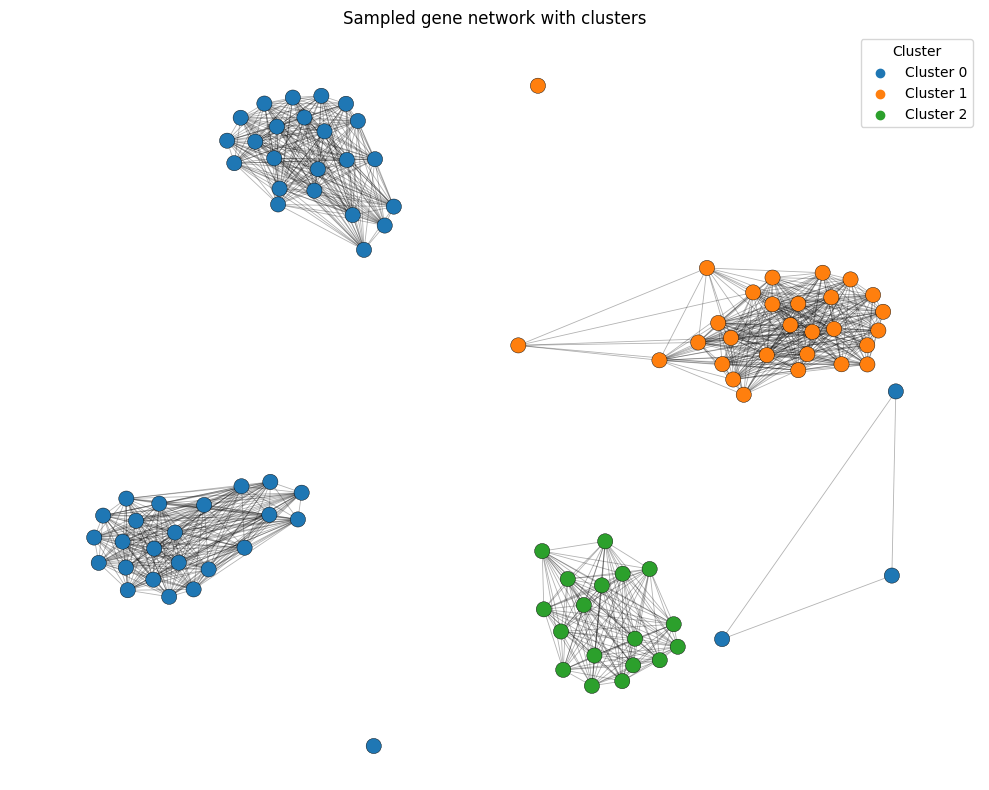

In [340]:
import matplotlib.pyplot as plt

N_GENES_PER_CLUSTER = 50
selected_genes = []

# Select top nodes per cluster
for c in sorted(Z_clean["cluster"].unique()):
    nodes_c = [n for n in G_full.nodes() if G_full.nodes[n]["cluster"] == c]
    degrees = {n: G_full.degree(n) for n in nodes_c}
    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:N_GENES_PER_CLUSTER]
    selected_genes.extend(top_nodes)

G_small = G_full.subgraph(selected_genes).copy()

print("Nodes in reduced graph:", G_small.number_of_nodes())
print("Edges in reduced graph:", G_small.number_of_edges())

cluster_palette = {
    "0": "#1f77b4",
    "1": "#ff7f0e",
    "2": "#2ca02c"
}

clusters = nx.get_node_attributes(G_small, "cluster")
unique_clusters = sorted(set(clusters.values()))
node_colors = [cluster_palette[str(clusters[node])] for node in G_small.nodes()]

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_small, seed=42, k=0.6)

nx.draw_networkx_edges(G_small, pos, alpha=0.3, width=0.6)

nx.draw_networkx_nodes(
    G_small, pos,
    node_color=node_colors,
    node_size=120,
    edgecolors="black",
    linewidths=0.3
)

# Legend (FIXED)
for c in unique_clusters:
    plt.scatter([], [], color=cluster_palette[str(c)], label=f"Cluster {c}")

plt.legend(title="Cluster")
plt.title("Sampled gene network with clusters")
plt.axis("off")
plt.tight_layout()
plt.show()


K-MEANS

In [287]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(Z_scaled)

# add K-means clusters to Z_clean
Z_clean["kmeans_cluster"] = kmeans_labels

# distribution
unique, counts = np.unique(kmeans_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"K-Means cluster {c}: {n} genes")


K-Means cluster 0: 4570 genes
K-Means cluster 1: 29 genes
K-Means cluster 2: 584 genes


visualizzazione umap con k-means

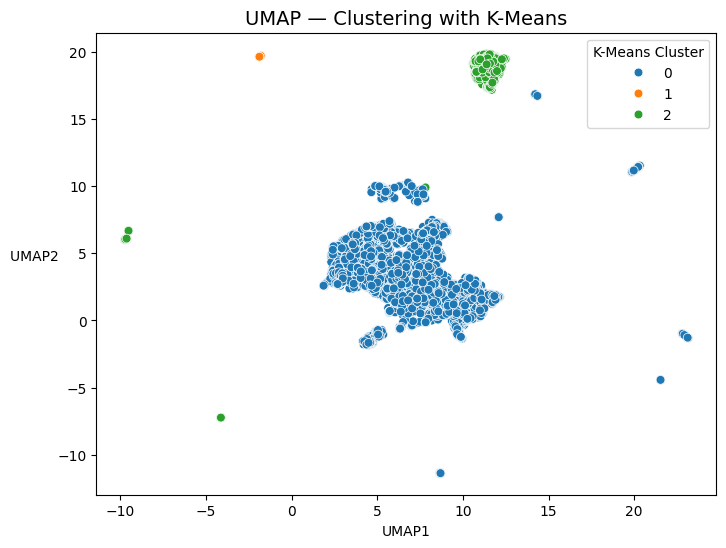

In [288]:
import matplotlib.pyplot as plt
import seaborn as sns

UMAP_df["kmeans_cluster"] = Z_clean["kmeans_cluster"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=UMAP_df,
    x="UMAP1", y="UMAP2",
    hue="kmeans_cluster",
    palette="tab10",
    s=40
)

plt.title("UMAP — Clustering with K-Means", fontsize=14)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2        ", rotation=0)
plt.legend(title="K-Means Cluster")
plt.show()


🔵 3) Heatmap di similarità ordinata per cluster K-Means

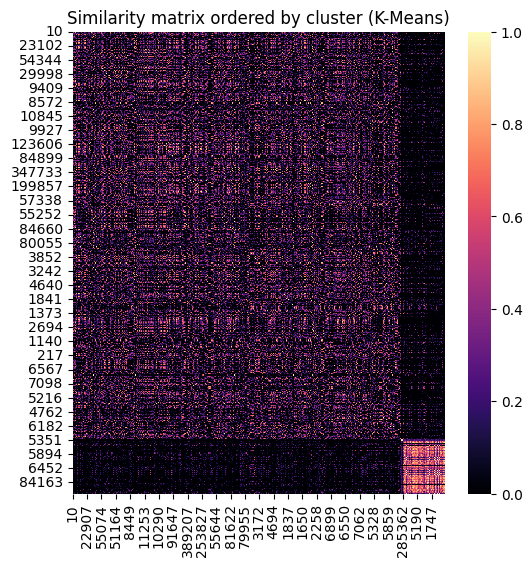

In [289]:
# restrict to genes used
sim_k = sim.loc[Z_clean.index, Z_clean.index]

# ordering by K-Means cluster
order_k = np.argsort(Z_clean["kmeans_cluster"].values)
genes_ordered_k = sim_k.index[order_k]

sim_ordered_k = sim_k.loc[genes_ordered_k, genes_ordered_k]

plt.figure(figsize=(6,6))
sns.heatmap(sim_ordered_k, cmap="magma", vmin=0, vmax=1)
plt.title("Similarity matrix ordered by cluster (K-Means)")
plt.show()


Confronto diretto: Spectral vs K-Means

In [294]:
comparison_df = Z_clean[["cluster", "kmeans_cluster"]].copy()
comparison_df


,cluster,kmeans_cluster
10,0,0
16,0,0
18,0,0
19,0,0
20,0,0
...,...,...
105371045,0,0
105804841,0,0
109580095,0,0
111365204,0,0


In [295]:
pd.crosstab(
    comparison_df["cluster"],
    comparison_df["kmeans_cluster"],
    rownames=["Spectral"], 
    colnames=["K-Means"]
)


K-Means,0,1,2
Spectral,,,
0,4570,0,566
1,0,29,0
2,0,0,18


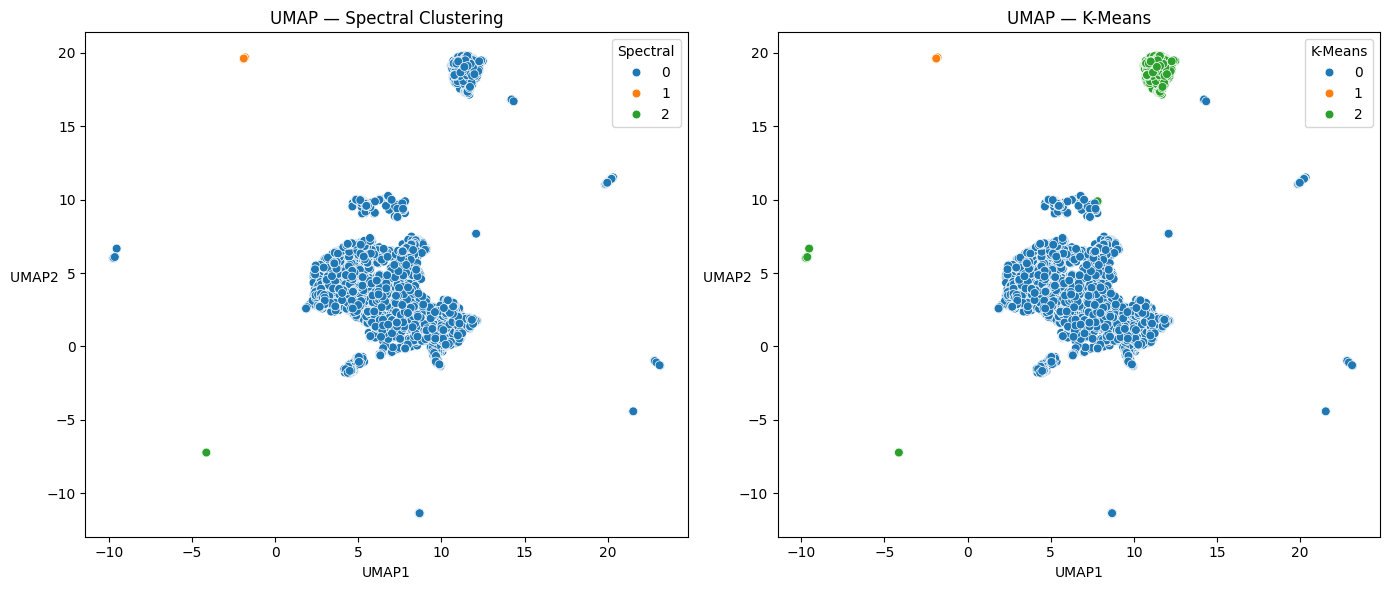

In [296]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Spectral
sns.scatterplot(
    ax=axes[0],
    data=UMAP_df,
    x="UMAP1", y="UMAP2",
    hue="cluster", palette="tab10",
    s=40
)
axes[0].set_title("UMAP — Spectral Clustering")
axes[0].legend(title="Spectral", bbox_to_anchor=(1,1))
axes[0].set_ylabel("UMAP2   ", rotation=0)

# K-Means
sns.scatterplot(
    ax=axes[1],
    data=UMAP_df,
    x="UMAP1", y="UMAP2",
    hue="kmeans_cluster", palette="tab10",
    s=40
)
axes[1].set_title("UMAP — K-Means")
axes[1].legend(title="K-Means", bbox_to_anchor=(1,1))
axes[1].set_ylabel("UMAP2   ", rotation=0)

plt.tight_layout()
plt.show()


LOGISTIC REGRESSION

In [297]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# =======================
# DATA
# =======================

X = Z_scaled                     # scaled MOFA factors
y = Z_clean["kmeans_cluster"].values    # target = K-Means cluster

# =======================
# LOGISTIC REGRESSION MODEL
# =======================

log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500,
    random_state=42
)

log_reg.fit(X, y)

# =======================
# ACCURACY
# =======================
pred = log_reg.predict(X)
acc = accuracy_score(y, pred)

print(f"Logistic Regression accuracy: {acc:.4f}\n")
print(classification_report(y, pred))


Logistic Regression accuracy: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4570
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00       584

    accuracy                           1.00      5183
   macro avg       1.00      1.00      1.00      5183
weighted avg       1.00      1.00      1.00      5183



Importanza dei fattori MOFA

In [298]:
coeffs = pd.DataFrame(
    log_reg.coef_,
    columns=[f"Factor_{i+1}" for i in range(X.shape[1])],
    index=[f"Cluster_{c}" for c in sorted(np.unique(y))]
)

coeffs


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15
Cluster_0,-1.256348,1.847084,0.036891,-0.043927,-0.020042,-0.011825,-0.176347,-0.016828,-0.458211,0.105736,0.026140,-0.015830,0.008010,-0.039770,-0.720407
Cluster_1,-0.045244,-0.039467,-0.025993,-0.000867,0.027028,0.000481,0.793528,-0.041222,-0.027757,0.018837,0.016109,-0.015205,0.000585,0.002951,-0.052619
Cluster_2,1.301593,-1.807618,-0.010899,0.044794,-0.006985,0.011344,-0.617181,0.058050,0.485969,-0.124573,-0.042249,0.031035,-0.008595,0.036820,0.773026


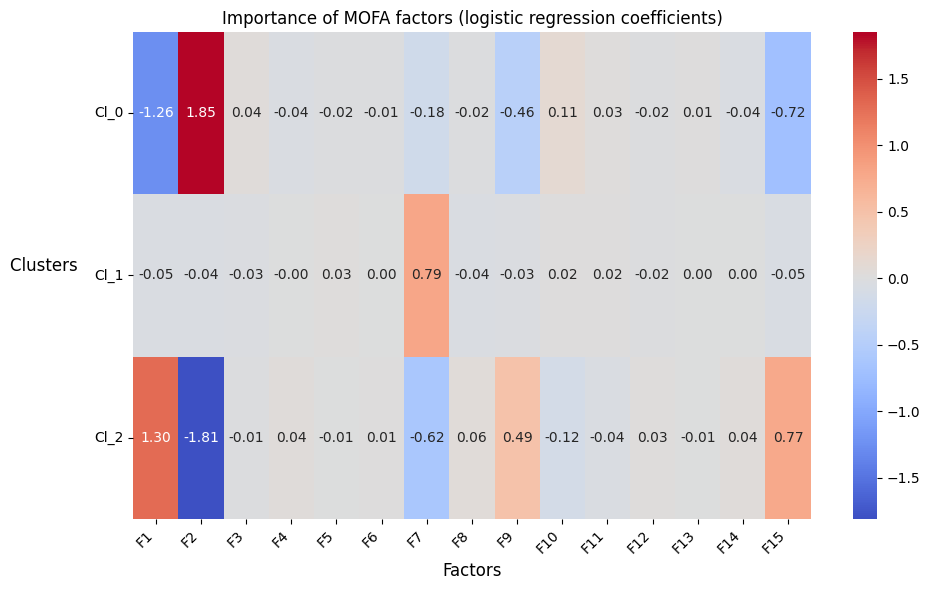

In [301]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# sns.heatmap(coeffs, cmap="coolwarm", center=0, annot=True, fmt=".2f")
# plt.title("Importance of MOFA factors (logistic regression coefficients)")
# plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.heatmap(
    coeffs,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

# Title
plt.title("Importance of MOFA factors (logistic regression coefficients)")

# Axis labels
ax.set_xlabel("Factors", fontsize=12)
ax.set_ylabel("Clusters                 ", fontsize=12, rotation=0)

# If you want to number factors as Factor_1, Factor_2, ...
ax.set_xticklabels(
    [f"F{i+1}" for i in range(len(coeffs.columns))],
    rotation=45,
    ha="right"
)

# Cluster numbering (Cl_0, Cl_1, ...)
ax.set_yticklabels(
    [f"Cl_{i}" for i in range(len(coeffs.index))],
    rotation=0
)

plt.tight_layout()
plt.show()


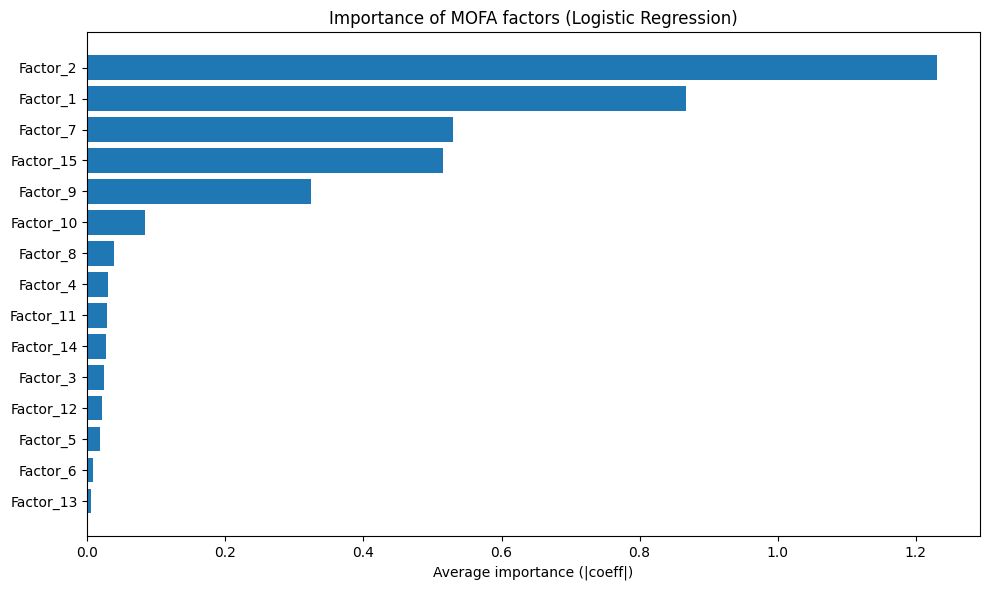

In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# mean absolute importance of coefficients
importance = coeffs.abs().mean(axis=0)

# sort from most to least important
importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(importance_sorted.index, importance_sorted.values)
plt.xlabel("Average importance (|coeff|)")
plt.title("Importance of MOFA factors (Logistic Regression)")
plt.tight_layout()
plt.show()


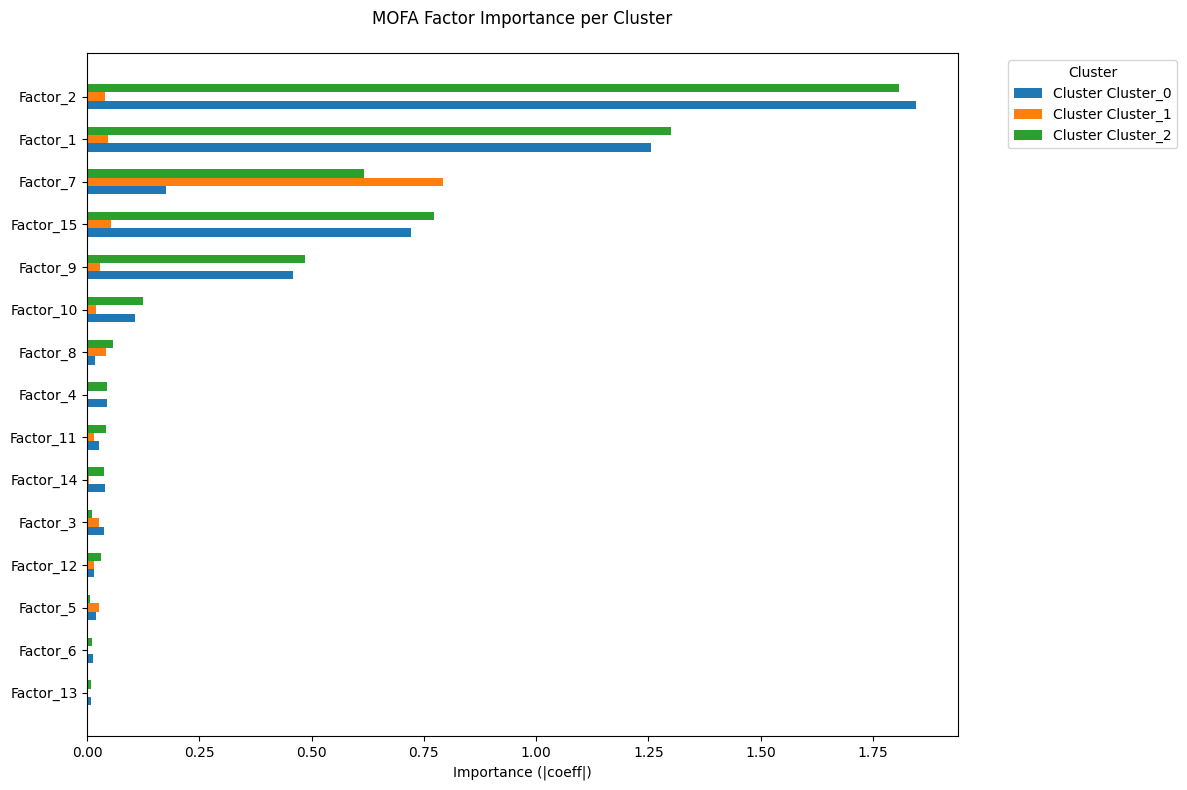

In [304]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Global average importance
# ----------------------------
importance = coeffs.abs().mean(axis=0)

# Global order (from least to most important)
order = importance.sort_values(ascending=True).index

# Reorder coeffs using the global order
coeffs_sorted = coeffs[order].abs()

# ----------------------------
# 2. Plotting parameters
# ----------------------------
bar_height = 0.35        # thinner bars
cluster_offset = 0.35     # spacing between clusters on the same factor
factor_spacing = 1.8      # spacing between different factors

clusters = coeffs_sorted.index
n_clusters = len(clusters)
n_factors = len(order)

# Y coordinates for factors (spaced)
base_y = np.arange(n_factors) * factor_spacing

plt.figure(figsize=(12, 8))

for i, cluster in enumerate(clusters):
    plt.barh(
        y=base_y + i * cluster_offset,     # increased spacing between clusters
        width=coeffs_sorted.loc[cluster],
        height=bar_height,
        label=f"Cluster {cluster}"
    )

plt.yticks(base_y + cluster_offset, order)

plt.xlabel("Importance (|coeff|)")
plt.title("MOFA Factor Importance per Cluster\n")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


prova vis 3d 

In [305]:
import numpy as np
import pandas as pd

# global average importance (absolute) for each factor
importance = coeffs.abs().mean(axis=0)

# take the top 3 most important factors
top3 = importance.sort_values(ascending=False).index[:3]
print("Top 3 factors:", top3.tolist())


Top 3 factors: ['Factor_2', 'Factor_1', 'Factor_7']


In [325]:
pip install plotly


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [341]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

# cast cluster to string to treat it as categorical
plot_df = Z_clean[[f1, f2, f3, "kmeans_cluster"]].copy()
plot_df["cluster_str"] = plot_df["kmeans_cluster"].astype(str)
plot_df["gene"] = plot_df.index  # for hover info

fig = px.scatter_3d(
    plot_df,
    x=f1,
    y=f2,
    z=f3,
    color="cluster_str",
    hover_name="gene",
    title=f"3D MOFA embedding on the 3 most important factors ({f1}, {f2}, {f3})",
    color_discrete_sequence=["#1f77b4", "#ff7f0e", "#2ca02c"]  # blue, orange, green
)

fig.update_traces(marker=dict(size=4, opacity=0.8))

fig.update_layout(
    legend_title_text="Cluster",
    scene=dict(
        xaxis_title=f1,
        yaxis_title=f2,
        zaxis_title=f3
    )
)

fig.show()


Boxplot dei fattori MOFA per cluster

Top 3 factors: ['Factor_2', 'Factor_1', 'Factor_7']
Global Y-range: -5.41 → 14.42


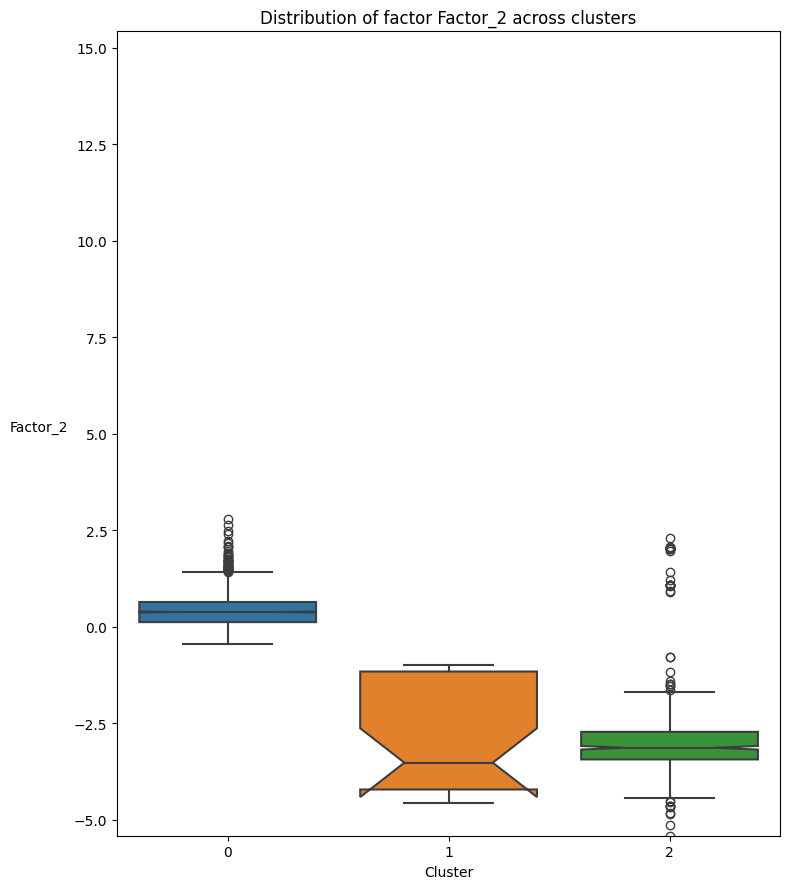

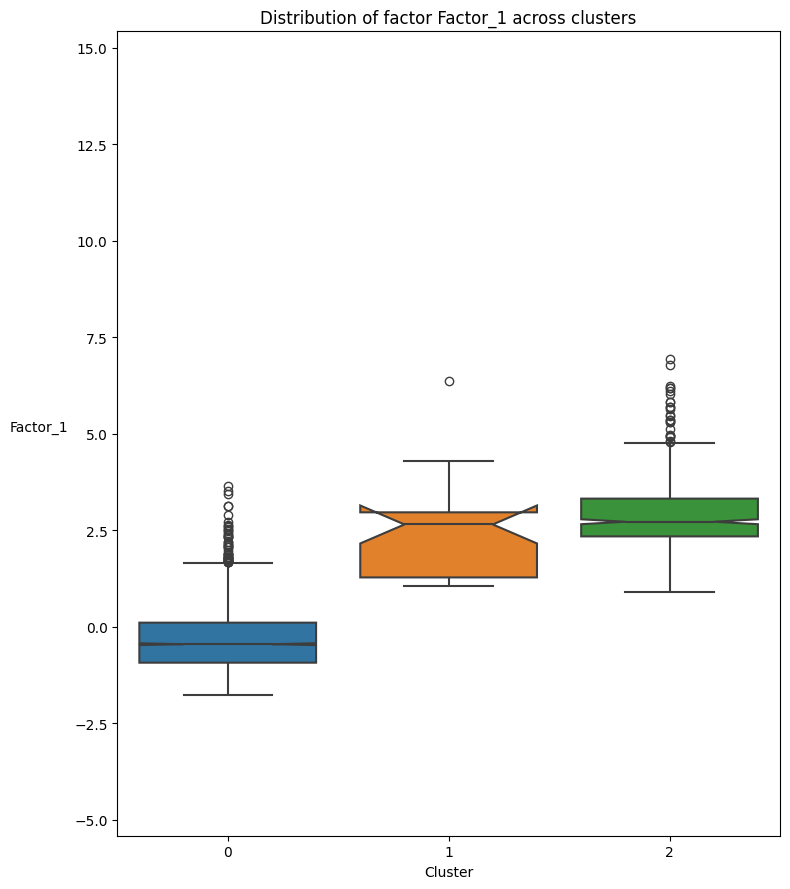

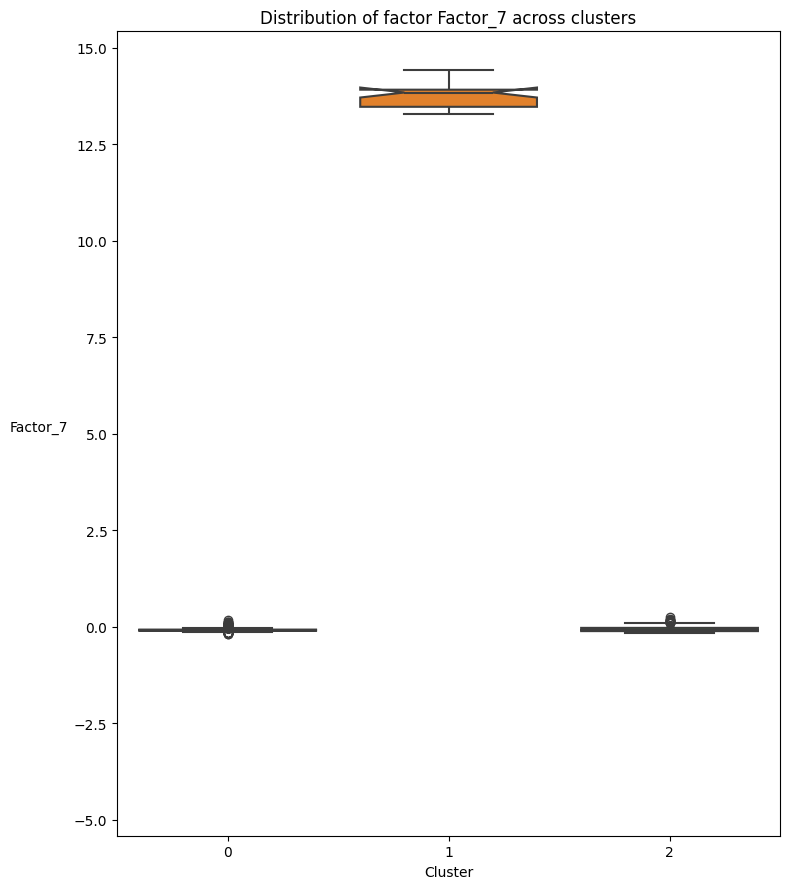

In [336]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------
# Step 1: Identify the 3 most important factors
# ---------------------------------------

importance = coeffs.abs().mean(axis=0)
top3 = importance.sort_values(ascending=False).index[:3]
print("Top 3 factors:", top3.tolist())

# ---------------------------------------
# Step 2: Prepare dataframe with only the top 3 factors
# ---------------------------------------

df_box = Z_clean.copy()
df_box["cluster"] = df_box["kmeans_cluster"].astype(str)

# ---------------------------------------
# Step 3: Color palette matching the bar plot
# ---------------------------------------

cluster_palette = {
    "0": "#1f77b4",  # blue
    "1": "#ff7f0e",  # orange
    "2": "#2ca02c"   # green
}

# ---------------------------------------
# Step 4: Compute uniform Y limits
# ---------------------------------------

global_ymin = df_box[top3].min().min()
global_ymax = df_box[top3].max().max()

print(f"Global Y-range: {global_ymin:.2f} → {global_ymax:.2f}")

# ---------------------------------------
# Step 5: Boxplots with uniform scale
# ---------------------------------------

for factor in top3:
    plt.figure(figsize=(8, 9))
    
    sns.boxplot(
        data=df_box,
        x="cluster",
        y=factor,
        palette=cluster_palette,
        notch=True,
        linewidth=1.5
    )
    
    plt.ylim(global_ymin, global_ymax+1)
    plt.title(f"Distribution of factor {factor} across clusters")
    plt.xlabel("Cluster")
    plt.ylabel(factor, labelpad=25, rotation=0)   # <-- More distance from the plot
    plt.tight_layout()
    plt.show()
